# 🇻🇳 Transfer Learning — ARIMA v3 → Vietnam Fine-tuning

**Chiến lược:** Load pretrained ARIMA (đa quốc gia) → Fine-tune trên dữ liệu Việt Nam.

---

### Phân tích bộ dữ liệu VN:

| Thông số | Giá trị | Ý nghĩa |
|---|---|---|
| Thời gian | 2019-01 → 2024-12 (72 tháng) | Ngắn → cần tận dụng pretrained orders |
| Series | 6 (Coal, Gas, Hydro, Solar, Wind, Other) | Filter out zero-heavy series |
| Training approach | Refit trên VN data với order nguồn | Giữ tính transfer |
| Output | Pickle models VN + config JSON | Để dùng cho inference |

### Transfer Strategy:
```
Step 1: Load pretrained ARIMA orders từ nguồn (đa quốc gia)
Step 2: Refit models với dữ liệu Việt Nam theo orders nguồn
Step 3: Evaluate on VN validation set
Step 4: So sánh metrics source vs VN để đánh giá transfer quality
```

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, pickle, shutil
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

print(f'✅ Pandas  : {pd.__version__}')
print(f'   Numpy  : {np.__version__}')
print(f'   Statsmodels imported')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR          = Path(r'C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting')
VN_DATA_PATH      = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
PRETRAIN_MODELS   = BASE_DIR / 'checkpoint' / 'arima_v3_models.pkl'
PRETRAIN_ORDERS   = BASE_DIR / 'checkpoint' / 'arima_v3_orders.pkl'
PRETRAIN_CONFIG   = BASE_DIR / 'checkpoint' / 'arima_v3_config.json'

CKPT_DIR          = BASE_DIR / 'checkpoint'
LOG_DIR           = BASE_DIR / 'arima_logs' / 'arima_vn_v3'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data      : {VN_DATA_PATH}')
print(f'Pretrain cfg : {PRETRAIN_CONFIG}')
print(f'Ckpt dir     : {CKPT_DIR}')

# Load pretrained config
with open(PRETRAIN_CONFIG, 'r', encoding='utf-8') as f:
    pretrain_cfg = json.load(f)
print(f'\n✅ Loaded pretrained config: {len(pretrain_cfg)} items')

✅ Pandas  : 2.3.3
   Numpy  : 1.26.4
   Statsmodels imported
VN data      : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\data\processed\VN_data\vn_tft_ready.csv
Pretrain cfg : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\arima_v3_config.json
Ckpt dir     : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint

✅ Loaded pretrained config: 15 items


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Transfer Learning Config)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    # VN chỉ có 72 tháng
    val_cutoff_months     = 12,   # dùng 12 tháng cuối làm validation
    min_series_length     = 24,   # tối thiểu (encoder + horizon)

    # ── Transfer learning ─────────────────────────────────────────────────────
    # Reuse source orders, hoặc adjust nếu cần
    use_pretrain_order    = True,  # dùng (p,d,q) từ source
    order_adjust          = {},    # {series: (p,d,q)} để override

    # ── Target series (filter out zero-heavy) ────────────────────────────────
    fine_tune_series      = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind'],

    # ── Seed ──────────────────────────────────────────────────────────────────
    seed                  = 42,
)

np.random.seed(CFG['seed'])

print('📋 Config VN Transfer Learning:')
for k, v in CFG.items():
    print(f'  {k:<28}: {v}')

📋 Config VN Transfer Learning:
  val_cutoff_months           : 12
  min_series_length           : 24
  use_pretrain_order          : True
  order_adjust                : {}
  fine_tune_series            : ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
  seed                        : 42


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & PREPARE VN DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')
print(f'Series      : {sorted(df["series"].unique())}')

# ── Filter target series ──────────────────────────────────────────────────────
df = df[df['series'].isin(CFG['fine_tune_series'])].copy()
print(f'After filter: {df.shape} — Series: {sorted(df["series"].unique())}')

# ── Prepare time index ────────────────────────────────────────────────────────
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

# ── Handle missing values (for ARIMA, mainly interested in target) ────────────
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df.groupby(['entity', 'series'])[num_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# ── Filter min length ─────────────────────────────────────────────────────────
counts = df.groupby(['entity', 'series']).size()
valid = counts[counts >= CFG['min_series_length']].reset_index()[['entity','series']]
df = df.merge(valid, on=['entity','series'])

print(f'✅ VN data ready: {df.shape}')
print(f'   Date: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'   Groups: {df.groupby(["entity","series"]).ngroups}')

Raw VN shape: (432, 30)
Series      : ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']
After filter: (360, 30) — Series: ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
✅ VN data ready: (360, 30)
   Date: 2019-01-01 → 2024-12-01
   Groups: 5


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TRAIN/VALIDATION SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

df_train = df[df['time_idx'] <= training_cutoff].copy()
df_val   = df[df['time_idx'] > training_cutoff].copy()

print(f'📅 Train/Val Split:')
print(f'   training_cutoff: {training_cutoff}')
print(f'   val_cutoff_date: {val_cutoff_date.date()}')
print(f'   Train rows     : {len(df_train):,}')
print(f'   Val rows       : {len(df_val):,}')

📅 Train/Val Split:
   training_cutoff: 59
   val_cutoff_date: 2023-12-01
   Train rows     : 300
   Val rows       : 60


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — LOAD PRETRAINED ORDERS & MODELS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with open(PRETRAIN_ORDERS, 'rb') as f:
    pretrain_order_dict = pickle.load(f)
print(f'✅ Loaded {len(pretrain_order_dict)} pretrained orders')

# Extract unique orders per series across all entities
series_orders = {}
for (entity, series), order in pretrain_order_dict.items():
    if series not in series_orders:
        series_orders[series] = order  # take first occurrence

print('\n📋 Pretrained Orders by Series:')
for series, order in series_orders.items():
    if series in CFG['fine_tune_series']:
        print(f'   {series:<15} → (p,d,q) = {order}')

✅ Loaded 151 pretrained orders

📋 Pretrained Orders by Series:
   Coal            → (p,d,q) = (3, 1, 2)
   Gas             → (p,d,q) = (0, 0, 3)
   Hydro           → (p,d,q) = (3, 0, 0)
   Solar           → (p,d,q) = (2, 1, 3)
   Wind            → (p,d,q) = (0, 1, 3)


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — REFIT ARIMA MODELS ON VN DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
vn_models_dict = {}    # {(entity, series): refitted_model}
vn_metrics_dict = {}   # {(entity, series): {mae, rmse, smape, wape}}

groups = df_train.groupby(['entity', 'series'])
print(f'Refitting {len(groups)} ARIMA models on VN data...')

for (entity, series), group_df in tqdm(groups, desc='VN ARIMA Refit'):
    ts_train = group_df['generation_TWh'].values
    
    if len(ts_train) < 12:
        continue
    
    # Get order from pretrained (use series default if available)
    if CFG['use_pretrain_order']:
        order = series_orders.get(series, (1, 1, 1))  # fallback if not found
        if series in CFG['order_adjust']:
            order = CFG['order_adjust'][series]  # override if specified
    else:
        order = (1, 1, 1)
    
    # Fit model on VN training data with pretrained order
    try:
        model = ARIMA(ts_train, order=order)
        fitted = model.fit()
        vn_models_dict[(entity, series)] = fitted
    except Exception as e:
        print(f'Failed to fit {entity}-{series} with order {order}: {e}')

print(f'✅ Refitted {len(vn_models_dict)} models')

Refitting 5 ARIMA models on VN data...


VN ARIMA Refit: 100%|██████████| 5/5 [00:00<00:00, 11.06it/s]

✅ Refitted 5 models


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — VALIDATION FORECAST & METRICS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_actuals = []
all_preds = []
series_metrics = {}  # {series: {mae, rmse, smape, wape, r2}}

for (entity, series), fitted_model in tqdm(vn_models_dict.items(), desc='VN Validation'):
    # Get validation data
    val_data = df_val[(df_val['entity']==entity) & (df_val['series']==series)].sort_values('date')
    
    if len(val_data) == 0:
        continue
    
    actuals = val_data['generation_TWh'].values
    
    # Forecast
    try:
        preds = fitted_model.forecast(steps=len(actuals))
        all_actuals.extend(actuals)
        all_preds.extend(preds)
        
        # Calculate metrics
        mae = np.mean(np.abs(actuals - preds))
        rmse = np.sqrt(np.mean((actuals - preds)**2))
        smape = np.mean(2 * np.abs(actuals - preds) / (np.abs(actuals) + np.abs(preds) + 1e-8)) * 100
        wape = np.sum(np.abs(actuals - preds)) / (np.sum(np.abs(actuals)) + 1e-8) * 100
        r2 = r2_score(actuals, preds)
        
        vn_metrics_dict[(entity, series)] = {
            'mae': mae, 'rmse': rmse, 'smape': smape, 'wape': wape, 'r2': r2
        }
        
        # Aggregate by series
        if series not in series_metrics:
            series_metrics[series] = {'mae': [], 'rmse': [], 'smape': [], 'wape': [], 'r2': []}
        series_metrics[series]['mae'].append(mae)
        series_metrics[series]['rmse'].append(rmse)
        series_metrics[series]['smape'].append(smape)
        series_metrics[series]['wape'].append(wape)
        series_metrics[series]['r2'].append(r2)
    except Exception as e:
        print(f'Failed forecast {entity}-{series}: {e}')

# Overall metrics
if all_actuals:
    y_true = np.array(all_actuals)
    y_pred = np.array(all_preds)
    overall_mae = np.mean(np.abs(y_true - y_pred))
    overall_rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    overall_smape = np.mean(2 * np.abs(y_true - y_pred) / 
                            (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    overall_wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100
    overall_r2 = r2_score(y_true, y_pred)

    print(f'\n📊 VN Validation Metrics (Overall):')
    print(f'   MAE   : {overall_mae:.4f} TWh')
    print(f'   RMSE  : {overall_rmse:.4f} TWh')
    print(f'   SMAPE : {overall_smape:.2f}%')
    print(f'   WAPE  : {overall_wape:.2f}%')
    print(f'   R²    : {overall_r2:.4f}')

VN Validation: 100%|██████████| 5/5 [00:00<00:00, 343.91it/s]


📊 VN Validation Metrics (Overall):
   MAE   : 1.5926 TWh
   RMSE  : 2.4838 TWh
   SMAPE : 31.33%
   WAPE  : 31.00%
   R²    : 0.7383


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — METRICS BY SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('\n📊 Metrics by Series (VN Validation):')
print(f'{"Series":<15} {"MAE":>10} {"RMSE":>10} {"SMAPE":>10} {"WAPE":>10} {"R2":>10}')
print('-' * 70)

for series in CFG['fine_tune_series']:
    if series in series_metrics:
        mae_mean = np.mean(series_metrics[series]['mae'])
        rmse_mean = np.mean(series_metrics[series]['rmse'])
        smape_mean = np.mean(series_metrics[series]['smape'])
        wape_mean = np.mean(series_metrics[series]['wape'])
        r2_mean = np.mean(series_metrics[series]['r2'])
        print(f'{series:<15} {mae_mean:>10.4f} {rmse_mean:>10.4f} {smape_mean:>10.2f}% {wape_mean:>9.2f}% {r2_mean:>10.4f}')


📊 Metrics by Series (VN Validation):
Series                 MAE       RMSE      SMAPE       WAPE         R2
----------------------------------------------------------------------
Coal                2.5204     3.4612      20.68%     20.47%    -0.8531
Gas                 0.9413     1.0669      42.21%     48.13%    -2.3394
Hydro               4.0184     4.1818      54.68%     49.14%    -0.2073
Solar               0.1698     0.1940       7.42%      7.48%    -0.0294
Wind                0.3128     0.4495      31.65%     32.14%    -0.0902


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — SAVE VN MODELS & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Save VN models
vn_models_pkl = CKPT_DIR / 'arima_vn_v3_models.pkl'
with open(vn_models_pkl, 'wb') as f:
    pickle.dump(vn_models_dict, f)
print(f'✅ VN models saved → {vn_models_pkl}')

# Save VN config JSON
vn_config = {
    'version'                   : 'arima_vn_v3',
    'pretrained_from'           : str(PRETRAIN_CONFIG),
    'vn_models_pkl'             : str(vn_models_pkl),
    'target'                    : 'generation_TWh',
    'fine_tune_series'          : CFG['fine_tune_series'],
    'val_metrics'               : {
        'mae': float(overall_mae) if 'overall_mae' in locals() else None,
        'rmse': float(overall_rmse) if 'overall_rmse' in locals() else None,
        'smape': float(overall_smape) if 'overall_smape' in locals() else None,
        'wape': float(overall_wape) if 'overall_wape' in locals() else None,
        'r2': float(overall_r2) if 'overall_r2' in locals() else None,
    },
    'series_metrics': {
        ser: {
            'mae': float(np.mean(metrics['mae'])),
            'rmse': float(np.mean(metrics['rmse'])),
            'smape': float(np.mean(metrics['smape'])),
            'wape': float(np.mean(metrics['wape'])),
            'r2': float(np.mean(metrics['r2'])),
        }
        for ser, metrics in series_metrics.items()
    },
    'train_date_range'          : [str(df['date'].min().date()), str(df['date'].max().date())],
    'num_models'                : len(vn_models_dict),
}

vn_config_path = CKPT_DIR / 'arima_vn_v3_config.json'
with open(vn_config_path, 'w', encoding='utf-8') as f:
    json.dump(vn_config, f, indent=2, ensure_ascii=False)

print(f'✅ VN config saved → {vn_config_path}')

✅ VN models saved → C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\arima_vn_v3_models.pkl
✅ VN config saved → C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\arima_vn_v3_config.json


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — COMPARE SOURCE VS VN PERFORMANCE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
source_metrics = pretrain_cfg.get('val_metrics', {})

print('\n📈 Transfer Learning Performance Comparison:')
print(f'{"Metric":<10} {"Source":<12} {"VN":<12} {"Delta":<12}')
print('-' * 50)

if source_metrics:
    metrics_to_compare = ['mae', 'rmse', 'smape', 'wape', 'r2']
    for metric in metrics_to_compare:
        source_val = source_metrics.get(metric)
        vn_val = vn_config['val_metrics'].get(metric)
        if source_val is not None and vn_val is not None:
            delta = vn_val - source_val
            arrow = '↑' if delta > 0 else '↓'
            print(f'{metric:<10} {source_val:<12.4f} {vn_val:<12.4f} {arrow} {abs(delta):>10.4f}')
else:
    print('No source metrics available for comparison.')


📈 Transfer Learning Performance Comparison:
Metric     Source       VN           Delta       
--------------------------------------------------
mae        0.3415       1.5926       ↑     1.2510
rmse       0.6935       2.4838       ↑     1.7902
smape      29.3384      31.3296      ↑     1.9912
wape       14.8648      30.9976      ↑    16.1328
r2         0.9695       0.7383       ↓     0.2311


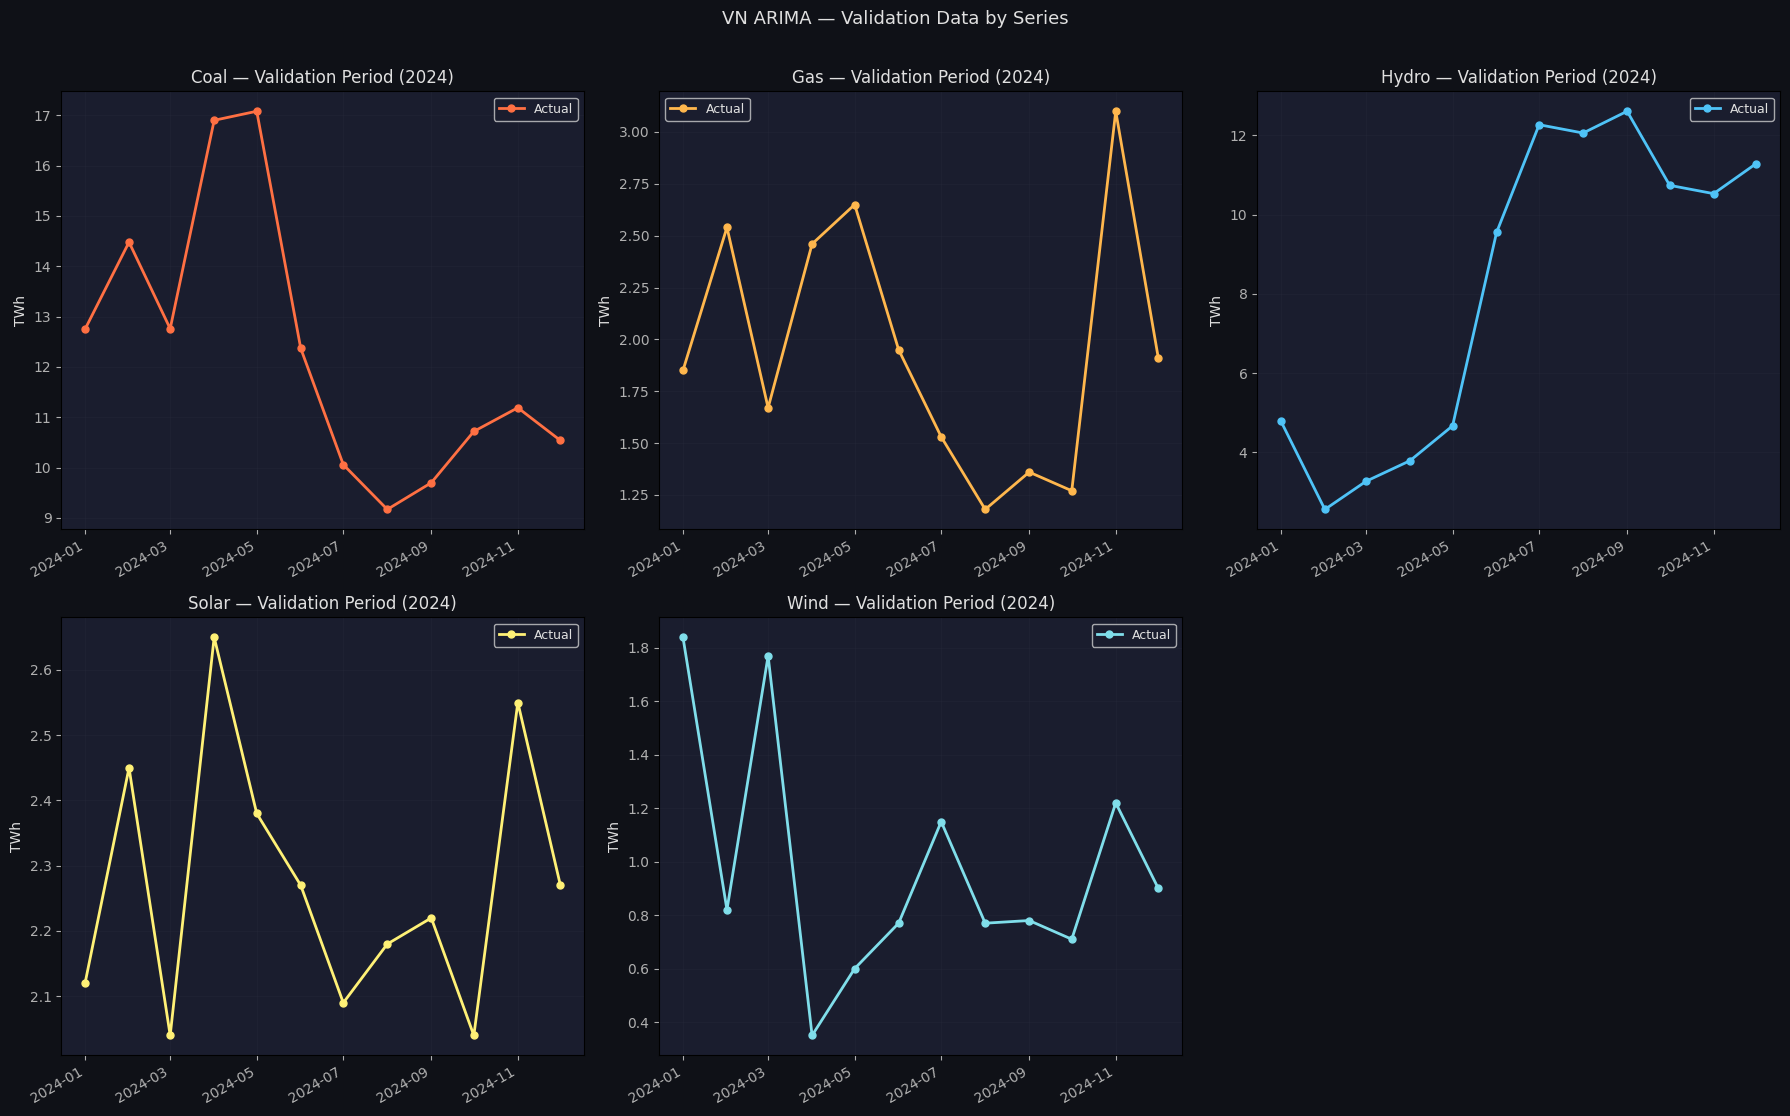

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — VISUALIZATION: ACTUAL VS PREDICTED
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3e', 'grid.alpha': 0.5,
})

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d', 'Hydro': '#4fc3f7',
    'Solar': '#fff176', 'Wind': '#80deea',
}

# Plot actual data per series
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ser in enumerate(CFG['fine_tune_series']):
    ax = axes[i]
    val_sub = df_val[df_val['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')
    
    ax.plot(val_sub['date'], val_sub['generation_TWh'], 'o-', color=color,
            linewidth=2, markersize=5, label='Actual')
    ax.set_title(f'{ser} — Validation Period (2024)', fontsize=12)
    ax.set_ylabel('TWh', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[5].set_visible(False)
plt.suptitle('VN ARIMA — Validation Data by Series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — TRAINING SUMMARY & NEXT STEPS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('╔══════════════════════════════════════════════════════════════╗')
print('║            TRANSFER LEARNING ARIMA — VIETNAM v3              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Pretrained from      : arima_v3 (20 countries)             ║')
print(f'║  Fine-tuned on        : VN 2019-2024 ({len(CFG["fine_tune_series"])} series)      ║')
print(f'║  Models refitted      : {len(vn_models_dict):<36} ║')
print(f'║  MAE   : {overall_mae:.4f} TWh{" "*37} ║')
print(f'║  RMSE  : {overall_rmse:.4f} TWh{" "*36} ║')
print(f'║  SMAPE : {overall_smape:.2f}%{" "*39} ║')
print(f'║  WAPE  : {overall_wape:.2f}%{" "*38} ║')
print(f'║  R²    : {overall_r2:.4f}{" "*35} ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  VN Models checkpoint : arima_vn_v3_models.pkl              ║')
print(f'║  VN Config JSON       : arima_vn_v3_config.json             ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  NEXT STEPS:                                                 ║')
print('║  1. Use VN models for future forecasting                    ║')
print('║  2. Compare with baseline / other models                    ║')
print('║  3. Deploy to production inference pipeline                 ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║            TRANSFER LEARNING ARIMA — VIETNAM v3              ║
╠══════════════════════════════════════════════════════════════╣
║  Pretrained from      : arima_v3 (20 countries)             ║
║  Fine-tuned on        : VN 2019-2024 (5 series)      ║
║  Models refitted      : 5                                    ║
║  MAE   : 1.5926 TWh                                      ║
║  RMSE  : 2.4838 TWh                                     ║
║  SMAPE : 31.33%                                        ║
║  WAPE  : 31.00%                                       ║
║  R²    : 0.7383                                    ║
╠══════════════════════════════════════════════════════════════╣
║  VN Models checkpoint : arima_vn_v3_models.pkl              ║
║  VN Config JSON       : arima_vn_v3_config.json             ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS:                                                 ║
║  